# Tracking a Panda in a Bamboo Grove: Exponential Smoothing vs. Running Mean

## Roman Branovets, Skoltech, 2025

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from math import sqrt
import sympy as sp

### Part I. Calm Walk: Learning the Panda’s Rhythm

1. Generating a true trajectory of a walking panda X_i, using a random walk model:
$$X_i=\ X_{i-1}+\ w_i$$
$w_i$ is normally distributed random noise with a mean of zero and a variance of $\sigma_w^2=11$
Initial condition $X_1=10$ m


In [2]:
#Creating arrays of trajectories. x1 is for a trajectory of 3000 points. x2 is for a trajectory of 300 points
np.random.seed(42)
x1 = np.zeros(3000)
x2 = np.zeros(300)
x1[0] = 10
x2[0] = 10

In [3]:
# bw is a variance of normally distributed random noise
# bt is a variace of normally distributed random noise from measurements
bw = 11
bt = 10

In [4]:
for i in range(1, 3000):
    x1[i] = x1[i - 1] + np.random.normal(0, sqrt(bw))
for i in range(1, 300):
    x2[i] = x2[i - 1] + np.random.normal(0, sqrt(bw))

2. Generating measurements $z_𝑖$ of the panda’s trajectory $𝑋_𝑖$, that represent a panda walking in a bamboo grove.
$$z_i=\ z_{i-1}+\ \eta_i$$
$\eta_i$ is normally distributed random noise with a mean of zero and a variance of $\sigma_\eta^2=10$


In [5]:
np.random.seed(43)
z1 = x1 + np.random.normal(0, sqrt(bt), 3000)
z2 = x2 + np.random.normal(0, sqrt(bt), 300)

3. Identification $\sigma_w^2$ and $\sigma_\eta^2$ using equations:
$$
\nu_i = Z_i - Z_{i-1}
$$

$$
\rho_i = Z_i - Z_{i-2}
$$

$$
E[\nu_i^2] \approx \frac{1}{N-1} \sum_{k=2}^N \nu_k^2
$$

$$
E[\rho_i^2] \approx \frac{1}{N-2} \sum_{k=3}^N \rho_k^2
$$

$$
E[\nu_i^2] = \sigma_W^2 + 2\sigma_\eta^2
$$

$$
E[\rho_i^2] = 2\sigma_W^2 + 2\sigma_\eta^2
$$

$$
\sigma_W^2 = E[\rho_i^2] - E[\nu_i^2]
$$

$$
\sigma_\eta^2 = \frac{2E[\nu_i^2] - E[\rho_i^2]}{2}
$$

In [6]:
# Function find_rand finds estimation bw and bt
def find_rand(z):
    n = len(z)
    #building nu and r
    v = np.zeros(n-1)
    r = np.zeros(n-2)
    for i in range(1, n):
        v[i-1] = z[i] - z[i - 1]
    for i in range(2, n):
        r[i-2] = z[i] - z[i - 2]
    #building mean squares of nu
    ev = (1 / (n - 1)) * np.sum(v ** 2)
    #building mean squares of r
    er = (1 / (n - 2)) * np.sum(r ** 2)
    bw, bt = sp.symbols('bw bt')
    equal1 = sp.Eq(bw + 2 * bt, ev)
    equal2 = sp.Eq(2 * bw + 2 * bt, er)
    sol = sp.solve((equal1, equal2), (bw, bt))
    return float(sol[bw]), float(sol[bt])

In [7]:
b1 = find_rand(z1)
b2 = find_rand(z2)
print(f'Variance of normally distributed random noise for 3000 steps: {b1[0]}\nVariance of normally distributed random noise from measurement for 3000 steps: {b1[1]}')
print(f'Variance of normally distributed random noise for 300 steps: {b2[0]}\nVariance of normally distributed random noise from measurement for 300 steps: {b2[1]}')
print(f"Difference at 3000 steps:\nBetween variances of normally distributed random noise: {b1[0] - bw}\nBetween variaces of normally distributed random noise from measurements: {b1[1] - bt}")
print(f"As a percentage:\nBetween variances of normally distributed random noise: {round(abs(b1[0] - bw)/bw*100, 2)}%\nBetween variances of normally distributed random noise from measurements: {round(abs(b1[1] - bt)/bt*100, 2)}%")
print(f"Difference at 300 steps:\nBetween variances of normally distributed random noise: {b2[0] - bw}\nBetween variaces of normally distributed random noise from measurements: {b2[1] - bt}")
print(f"As a percentage:\nBetween variances of normally distributed random noise: {round(abs(b2[0] - bw)/bw*100, 2)}%\nBetween variances of normally distributed random noise from measurements: {round(abs(b2[1] - bt)/bt*100, 2)}%")

Variance of normally distributed random noise for 3000 steps: 10.4270643014677
Variance of normally distributed random noise from measurement for 3000 steps: 9.9264916554493
Variance of normally distributed random noise for 300 steps: 10.9121438969243
Variance of normally distributed random noise from measurement for 300 steps: 13.1720690099654
Difference at 3000 steps:
Between variances of normally distributed random noise: -0.5729356985322998
Between variaces of normally distributed random noise from measurements: -0.07350834455069943
As a percentage:
Between variances of normally distributed random noise: 5.21%
Between variances of normally distributed random noise from measurements: 0.74%
Difference at 300 steps:
Between variances of normally distributed random noise: -0.08785610307569947
Between variaces of normally distributed random noise from measurements: 3.1720690099653996
As a percentage:
Between variances of normally distributed random noise: 0.8%
Between variances of norma

For 3000 steps:
$$\sigma_w^2=10.4270643014677$$
$$\sigma_\eta^2=9.9264916554493$$
For 300 steps:
$$\sigma_w^2=10.9121438969243$$
$$\sigma_\eta^2=13.1720690099654$$
Difference at 3000 steps as a percentage:\
Between variances of normally distributed random noise: 5.21%\
Between variances of normally distributed random noise from measurements: 0.74%\
Difference at 300 steps as a percentage:\
Between variances of normally distributed random noise: 0.8%\
Between variances of normally distributed random noise from measurements: 31.72%


For 300 steps, the variance of normally distributed random noise from measurements was higher than the variance of normally distributed random noise from measurements for 3000 steps. For 3000 steps, we see that the variance of normally distributed random noise from measurements is almost equal to the true one. Thus, the accuracy decreased with a decrease in the number of steps. However, estimated variances of state noise turned out to be close to the true values.

4. Determining the optimal smoothing coefficient for exponential smoothing

$$
\begin{aligned}
\alpha &= \frac{-\chi+\sqrt{\chi^2+4\chi}}{2} \\
\chi &= \frac{\sigma_w^2}{\sigma_{\eta}^2}
\end{aligned}
$$

In [8]:
def find_alpha(b):
    x=b[0]/b[1]
    al=(-x+sqrt(x**2+4*x))/2
    return al

In [9]:
# for 3000 points 
al1=find_alpha(b1)
print(f'Optimal smoothing coefficient alpha for 3000 points: {al1}')
# for 300 points
al2=find_alpha(b2)
print(f'Optimal smoothing coefficient alpha for 300 points: {al2}')

Optimal smoothing coefficient alpha for 3000 points: 0.6264273191237199
Optimal smoothing coefficient alpha for 300 points: 0.5857871395087532


5.	Performing exponential smoothing using the determined smoothing coefficient.

In [10]:
def find_exp(z, al):
    n=len(z)
    x_exp=np.zeros(n)
    x_exp[0]=z[0]
    for i in range(1,n):
        x_exp[i]=x_exp[i-1]+al*(z[i]-x_exp[i-1])
    return x_exp

In [11]:
# for 3000 points 
x_exp1=find_exp(z1,al1)
# for 300 points
x_exp2=find_exp(z2, al2)

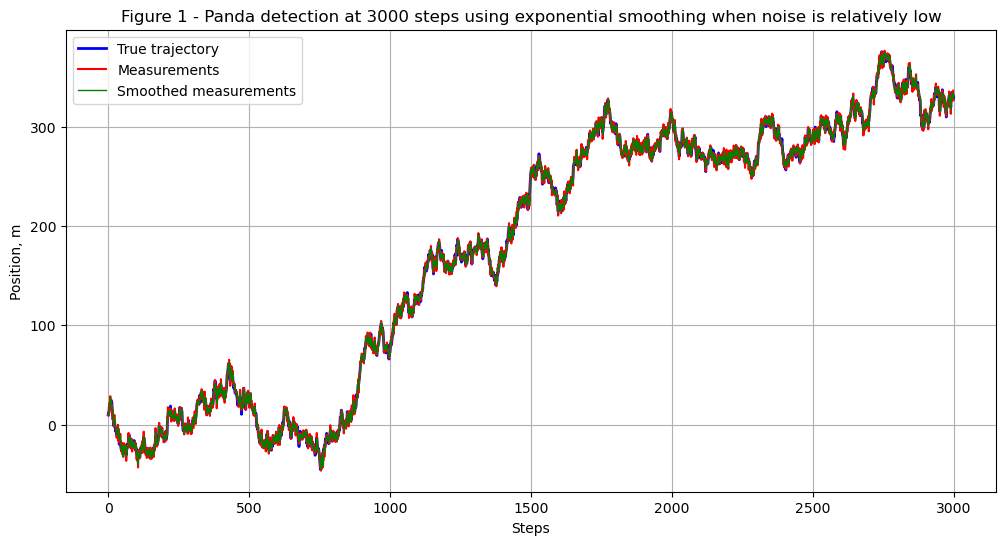

In [12]:
# plot of Panda detection at 3000 steps using exponential smoothing when noise is relatively low
plt.figure(figsize=(12, 6))
plt.plot(x1, color="blue",linewidth=2.0,  label='True trajectory')
plt.plot(z1, color='red',linewidth=1.5,  label='Measurements')
plt.plot(x_exp1, color='green', linewidth=1.0, label='Smoothed measurements')
plt.title('Figure 1 - Panda detection at 3000 steps using exponential smoothing when noise is relatively low')
plt.xlabel('Steps')
plt.ylabel('Position, m')
plt.legend()
plt.grid()
plt.show()

It is hard to see differences between smoothed data and raw data. Let's see the same plot on a larger scale

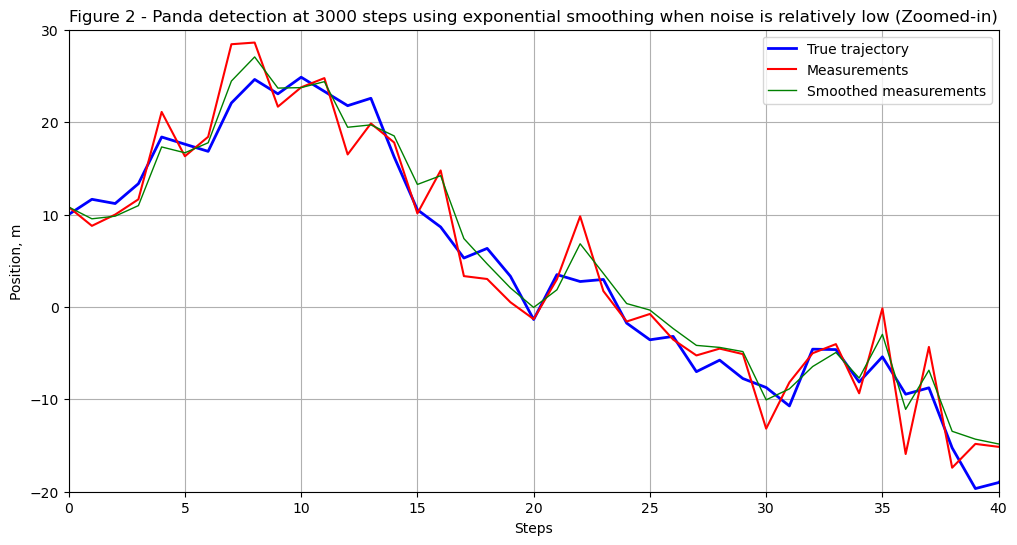

In [13]:
# plot of Panda detection at 3000 steps using exponential smoothing when noise is relatively low (Zoomed in)
plt.figure(figsize=(12, 6))
plt.plot(x1, color="blue",linewidth=2.0,  label='True trajectory')
plt.plot(z1, color='red',linewidth=1.5,  label='Measurements')
plt.plot(x_exp1, color='green', linewidth=1.0, label='Smoothed measurements')
plt.title('Figure 2 - Panda detection at 3000 steps using exponential smoothing when noise is relatively low (Zoomed-in)')
plt.xlabel('Steps')
plt.ylabel('Position, m')
plt.xlim(0,40)
plt.ylim(-20,30)
plt.legend()
plt.grid()
plt.show()

We see that exponential smoothing has brought the measured data closer to the true values. With low measurement noise, the exponential smoothing method performs very well, there is no bias for the case of low noise.

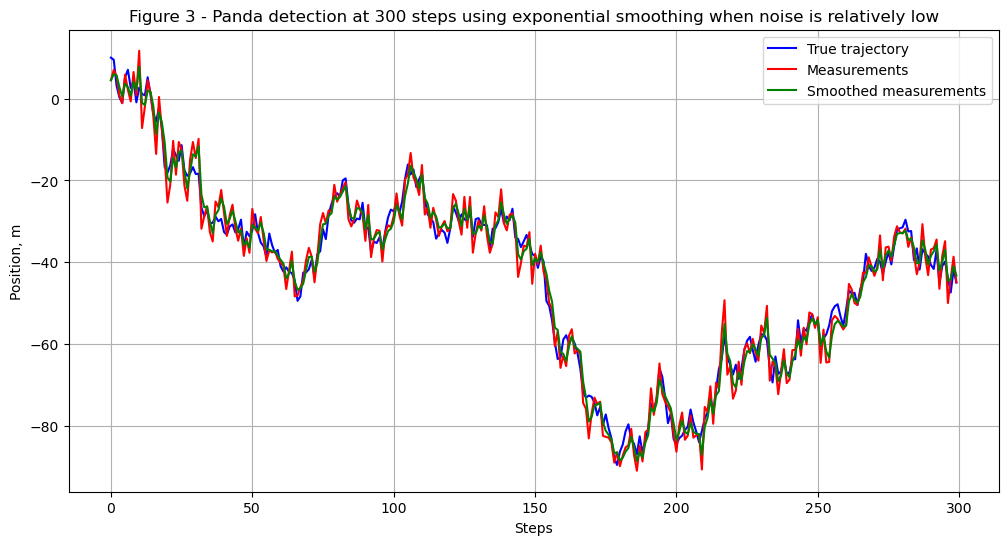

In [14]:
# plot of Panda detection at 300 steps using exponential smoothing when noise is relatively low
plt.figure(figsize=(12, 6))
plt.plot(x2, color="blue",  label='True trajectory')
plt.plot(z2, color='red',  label='Measurements')
plt.plot(x_exp2, color='green',  label='Smoothed measurements')
plt.title('Figure 3 - Panda detection at 300 steps using exponential smoothing when noise is relatively low')
plt.xlabel('Steps')
plt.ylabel('Position, m')
plt.legend()
plt.grid()
plt.show()

Let's again consider the same plot on a larger scale.

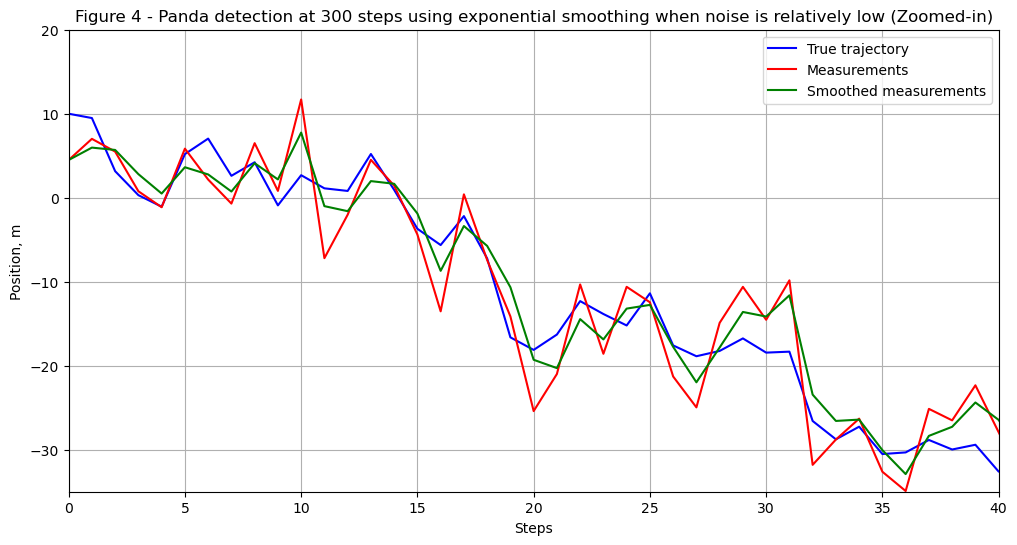

In [15]:
# plot of Panda detection at 300 steps using exponential smoothing when noise is relatively low (Zoomed in)
plt.figure(figsize=(12, 6))
plt.plot(x2, color="blue",  label='True trajectory')
plt.plot(z2, color='red',  label='Measurements')
plt.plot(x_exp2, color='green',  label='Smoothed measurements')
plt.title('Figure 4 - Panda detection at 300 steps using exponential smoothing when noise is relatively low (Zoomed-in)')
plt.xlabel('Steps')
plt.ylabel('Position, m')
plt.legend()
plt.xlim(0,40)
plt.ylim(-35,20)
plt.grid()
plt.show()

We again see that exponential smoothing has brought the measured data closer to the real values. With low measurement noise, the exponential smoothing method performs very well, there is no bias for the case of low noise.

Conclusion: We have simulated a random walk process and measured it with random noise measurements. We have estimated $\sigma_w^2$ and $\sigma_\eta^2$ and they turned out to be close to the true values. We observed that when we estimated variances, the accuracy decreased with a decrease in the number of steps. After that we used these values to find  optimal smoothing coefficient, and performed exponential smoothing and plot the data. Exponential smoothing has brought the measured data closer to the real values. With low measurement noise, the exponential smoothing method performs very well, there is no bias for the case of low noise.

### Part II – Shaky Cameras: Testing Under Harsh Conditions

1. Generating a new true trajectory, $X_i$ , of a walking panda, using the random walk model with much higher noise.
$$X_i= X_{i-1}+ w_i$$
Initial condition $X_1=10$ m\
$w_i$ is normally distributed random noise with a mean of zero and a variance of $\sigma_w^2={28}^2$


In [16]:
x = np.zeros(300)
x[0] = 10
np.random.seed(44)
for i in range(1,300):
    x[i]=x[i-1]+np.random.normal(0, 28)

2. Generating measurements $z_i$ of the panda’s trajectory $X_i$, that represents a panda walking in a bamboo grove
$$z_i=z_{i-1}+\eta_i$$
$\eta_i$ is normally distributed random noise with a mean of zero and a variance of $\sigma_\eta^2={97}^2$


In [17]:
np.random.seed(45)
z=x+np.random.normal(0, 97, 300)

3. Determining the optimal smoothing coefficient alpha

Determining the component of full error related to measurement errors

In [18]:
al=find_alpha([28**2,97**2])
print(f'Optimal smoothing coefficient alpha: {al}')
# bes is component of full error related to measurement errors for Exponential smoothing
bes=(97**2)*(al/(2-al))
print(f'Component of full error related to measurement errors: {bes}')

Optimal smoothing coefficient alpha: 0.24998861233121078
Component of full error related to measurement errors: 1344.072884324301


4. Finding the matching running mean window size M so that measurement-error
contributions are comparable.

Firstly, we have found the component of the full error related to measurement errors for exponential smoothing:

$$
\sigma_{ES}^{2}=\sigma_{\eta}^{2}\frac{\alpha}{2-\alpha}
$$

$$
\sigma_{ES}^{2}=1344.072884324301
$$

Then we have found running mean window according to these equations:

$$
\sigma_{RM}^{2}=\frac{\sigma_{\eta}^{2}}{M}
$$

$$
\sigma_{ES}^{2}=\sigma_{RM}^{2}
$$

In [19]:
# M is running mean window
M = round((2-al)/al)
print(f'Running mean window: {M}')

Running mean window: 7


5. Applying the running mean using the determined window size $M$ and the exponential mean using the determined smoothing constant $\alpha$ on the measurements $z_i$

Applying the exponential smoothing

In [20]:
x_exp=find_exp(z,al)

Applying the running mean with window size 7\
The first 3 points and the last 3 points are found as the average of the first 3 points and the last 3
points respectively

In [21]:
n=len(z)
x_mean=np.zeros(n)
x_mean[:3]=(np.sum(z[0:3])/3)
x_mean[n-3:n]=(np.sum(z[n-3:n])/3)
for i in range(3,n-3):
    x_mean[i]=(1/M)*np.sum(z[i-((M-1)//2)-1:i+((M-1)//2)])

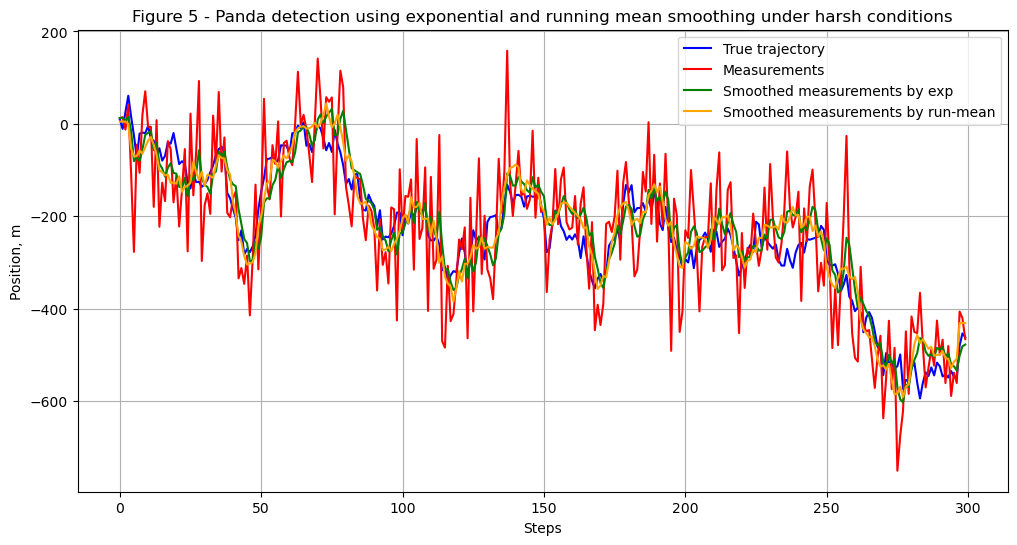

In [22]:
#plot of Panda detection using exponential and running mean smoothing in harsh conditions
plt.figure(figsize=(12, 6))
plt.plot(x, color="blue",  label='True trajectory')
plt.plot(z, color='red',  label='Measurements')
plt.plot(x_exp, color='green',  label='Smoothed measurements by exp')
plt.plot(x_mean, color='orange',  label='Smoothed measurements by run-mean')
plt.title('Figure 5 - Panda detection using exponential and running mean smoothing under harsh conditions')
plt.xlabel('Steps')
plt.ylabel('Position, m')
plt.legend()
plt.grid()
plt.show()

It is hard to see differences between smoothed and raw data. Let's see the same plot on a larger scale

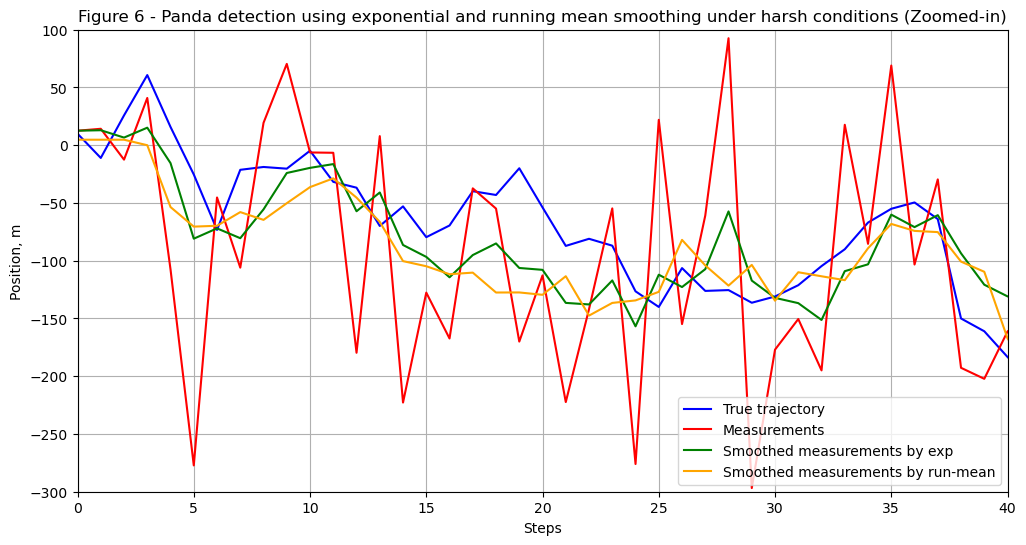

In [23]:
# plot of Panda detection using exponential and running mean smoothing in harsh conditions (Zoomed-in)
plt.figure(figsize=(12, 6))
plt.plot(x, color="blue",  label='True trajectory')
plt.plot(z, color='red',  label='Measurements')
plt.plot(x_exp, color='green',  label='Smoothed measurements by exp')
plt.plot(x_mean, color='orange',  label='Smoothed measurements by run-mean')
plt.title('Figure 6 - Panda detection using exponential and running mean smoothing under harsh conditions (Zoomed-in)')
plt.xlabel('Steps')
plt.ylabel('Position, m')
plt.legend()
plt.xlim(0,40)
plt.ylim(-300,100)
plt.grid()
plt.show()

6.	With a lot of noise, the running mean method performs better because it has no bias, while the exponential smoothing method has bias. That is why the running mean method is closer to the true trajectory in case of harsh conditions(when noise is high).

**Conclusions:**

First, we have learned how to apply exponential smoothing and running mean methods in conditions of uncertainty. Second, by comparing their errors, we determined the most effective quasi-optimal estimation method (between exponential and running mean) for different situations with uncertainty. Third, we learned that while the smoothing methods themselves are simple to implement, choosing the right one for a specific task requires detailed and careful analysis beforehand.\
Thus, we can conclude that everything depends on the nature of our data changes, and each method requires choosing the best parameter to obtain the cleanest data possible. With a lot of noise, the running mean method performs better because it has no bias, while the exponential smoothing method has bias. That is why the running mean method is closer to the true trajectory in case of harsh conditions(when noise is high). In turn, the exponential smoothing method gives better results in the case of relatively small noise.

**Learning log:**

What we learned:

We have mastered the technique of estimating the variances of process noise and measurement noise  directly from noisy data. We studied how exponential filter and running mean filter work. We learned how to calculate the optimal smoothing coefficient α for exponential smoothing based on the ratio of noise variances. We also studied how filtering changes the quality of data after processing. We conducted a comparative analysis of the two methods, choosing the window size for the moving average so that its measurement error was comparable to the error of exponential smoothing.\
We have found that there is no single best method for all situations. In this trajectory, exponential smoothing generally showed better results on a smooth trajectory, while a moving average could be more effective with sudden data jumps.

What difficulties we faced:

It was difficult for us to understand how well the filtering was applied to the data, since there were changes both in the magnitude and in the frequency of dynamic changes\
When implementing the running mean algorithm, there was a technical difficulty with processing the beginning and end of the data array, where there are not enough points to fill the entire window. To do this, we had to use separate calculations for the first and last few points.\
It was not easy to make an unambiguous conclusion about the advantage of one method over another, since their behavior differed in different parts of the trajectory. This required a thorough analysis of the graphs and an understanding of the nature of the methodological error of each of the filters.
